### Разведовательный анализ датасета (EDA)
- Цель: Узнать базовую инфомрацию об используемом датасете
- Данные: trashnet датасет, см. `data/data_description.md` для подробностей

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 42
DATA_DIR = "../data/trashnet"

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

Device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
# Загружаем датасет и создаем dataloader

dataset = ImageFolder(DATA_DIR,transform=transforms.ToTensor())

generator=torch.Generator().manual_seed(RANDOM_STATE)
loader = DataLoader(dataset,
                         batch_size=30,
                         num_workers=0,
                         shuffle=True,
                         generator=generator)
class_names = dataset.classes

print(f"Размер датасета: {len(dataset)}")
print(f"Классы в датасете:  {', '.join(name for name in class_names)}")
unique, counts = np.unique(np.array(dataset.targets), return_counts=True)
print(f"Процентное соотношение: {', '.join(f'{percent:.2f}%' for percent in counts/len(dataset)*100)}")

Размер датасета: 2527
Классы в датасете:  cardboard, glass, metal, paper, plastic, trash
Процентное соотношение: 15.95%, 19.83%, 16.22%, 23.51%, 19.07%, 5.42%


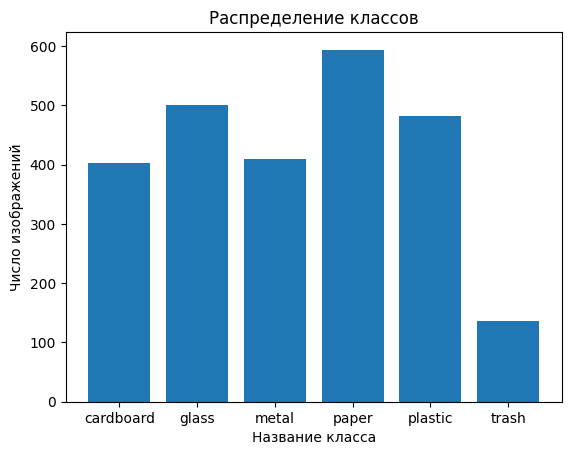

In [7]:

plt.bar(class_names,counts)
plt.title("Распределение классов")
plt.ylabel("Число изображений")
plt.xlabel("Название класса")
plt.show()

In [3]:
# Вычисляем нормализацию для нашего датасета 

n_samples = 0
mean = 0.0
var = 0.0
with torch.no_grad():
    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        
        # Обновление среднего и дисперсии по методу Welford
        batch_mean = images.mean([0, 2])
        batch_var = images.var([0, 2], unbiased=False)
        
        # Обновление глобальных статистик
        new_n = n_samples + batch_samples
        delta = batch_mean - mean
        mean = mean + delta * batch_samples / new_n
        var = (n_samples * var + batch_samples * batch_var + 
            n_samples * batch_samples * delta**2 / new_n) / new_n
        n_samples = new_n


std = torch.sqrt(var)
TRASHNET_MEAN = tuple(mean.tolist())
TRASHNET_STD = tuple(std.tolist())
TRASHNET_IMG_SIZE = tuple(dataset[0][0][0].size())

print(f"TRASHNET_MEAN = ({' '.join(f'{f:.3f}' for f in TRASHNET_MEAN)})")
print(f"TRASHNET_STD = ({' '.join(f'{f:.3f}' for f in TRASHNET_STD)})")
print(f"TRASHNET_IMG_SIZE = ({' '.join(str(f) for f in TRASHNET_IMG_SIZE)})")

TRASHNET_MEAN = (0.673 0.640 0.605)
TRASHNET_STD = (0.209 0.210 0.232)
TRASHNET_IMG_SIZE = (384 512)


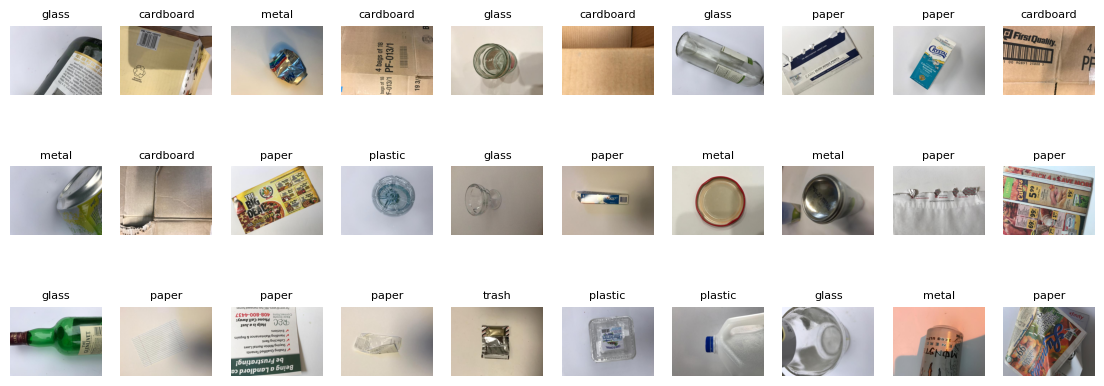

In [ ]:
# Выводим примеры изображений

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x=[]
    y=[]
    for i in range(n//loader.batch_size +1):
        x_temp, y_temp = next(iter(loader))
        x.extend(x_temp[:n].cpu()) 
        y.extend(y_temp[:n].cpu()) 

    plt.figure(figsize=(14, 2*n//10+1))
    for i in range(n):
        plt.subplot(n//10+1, 10, i + 1)
        img = x[i].clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.savefig("../data/trashnet_preview.png")
    plt.show()

show_images(loader,30)


### Выводы
---   
Датасет состоит из `2527` изображений, разделенных на `6` классов.  
Соотношение классов примерное одинаковое, исключением является класс `trash`.  
Для датасета были посчитаны значения, которые будут использоваться для нормализации в дальнейшем.  
Также при просмотре примеров изображений, можно заметить, что многоие фотографии содержут объекты, не попадающие полностью в кадр, поэтому при применении аугментаций нужно быть осторожным с обрезкой изображений, чтобы случайно не вырезать объект.  

